### Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from improved_diffusion.temporal_script_util import (
    temporal_model_and_diffusion_defaults,
    create_temporal_model_and_diffusion,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Parameters

In [15]:
SEQUENCE_LENGTH = 10240
# CHECKPOINT_PATH = '/u/scratch1/tan583/improved-diffusion-main/models_2/model010000.pt'
# CHECKPOINT_PATH = '/u/scratch1/tan583/improved-diffusion-main/models_2/model_best.pt'
# CHECKPOINT_PATH = '/u/scratch1/tan583/improved-diffusion-main/10k_log_old2/model070000.pt'
CHECKPOINT_PATH = '/u/scratch1/tan583/improved-diffusion-main/models_colab/model035000.pt'
# train_data = torch.load('/u/scratch1/tan583/improved-diffusion-main/data/new_log_flux_dataset.pt') 
train_data = torch.load('/u/scratch1/tan583/improved-diffusion-main/data/10K_normalized_log_flux_dataset.pt')
NUM_SAMPLES = 128
USE_DDIM = True
DDIM_STEPS = 50

cfg = temporal_model_and_diffusion_defaults()
cfg.update(dict(
    sequence_length=SEQUENCE_LENGTH,
    num_channels=64,
    channel_mult="1,2,3,4,4",
    num_res_blocks=2,
    # attention_resolutions="640,320",
    attention_resolutions="1280, 640",
    # attention_resolutions="256, 128",
    diffusion_steps=1000,
    noise_schedule="linear",
    timestep_respacing=f"ddim{DDIM_STEPS}" if USE_DDIM else "",
))

/tmp/ipykernel_2704433/2340740145.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load('/u/scratch1/tan583/improved-diffusion-main/data/10K_normalized

### Loading Model & Sampling

In [16]:
model, diffusion = create_temporal_model_and_diffusion(**cfg)
state = torch.load(CHECKPOINT_PATH, map_location='cpu')
model.load_state_dict(state)
model.to(device).eval()

sample_fn = diffusion.ddim_sample_loop if USE_DDIM else diffusion.p_sample_loop
with torch.no_grad():
    samples = sample_fn(
        model,
        (NUM_SAMPLES, 1, SEQUENCE_LENGTH),
        clip_denoised=False,       # important: your data is raw log-flux, not in [-1,1]
        progress=True,
    )
samples_np = samples[:, 0].cpu().numpy()
print("Generated:", samples_np.shape, "range:", samples_np.min(), samples_np.max())

/tmp/ipykernel_2704433/1282132347.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CHECKPOINT_PATH, map_location='cpu')


  0%|          | 0/50 [00:00<?, ?it/s]

Generated: (128, 10240) range: -1.0592002 1.0627797


### Loading Training Dataset

In [17]:
# Load training data for comparison
if isinstance(train_data, dict):
    train_data = train_data['data']
train_np = train_data.numpy()

# Pick random training samples to compare against
rng = np.random.default_rng(0)
train_idx = rng.choice(len(train_np), size=NUM_SAMPLES, replace=False)
train_subset = train_np[train_idx]

### Plot Data Samples

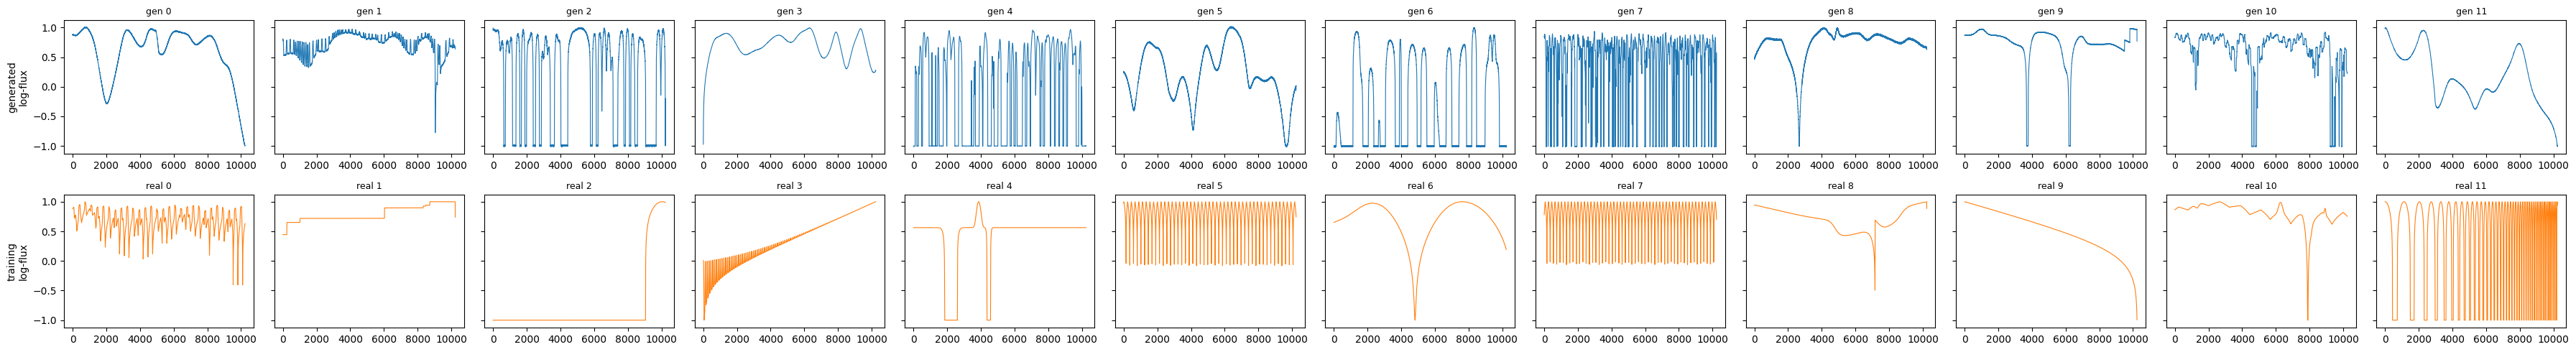

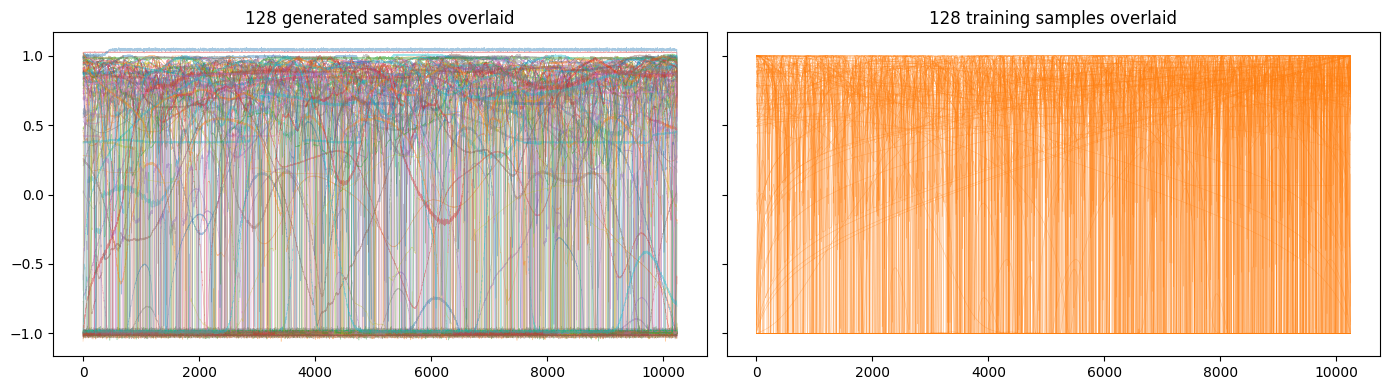

In [18]:
# Plot: top row = generated, bottom row = real
n_show = 12
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 5), sharey=True)
for i in range(n_show):
    axes[0, i].plot(samples_np[i], lw=0.8)
    axes[0, i].set_title(f"gen {i}", fontsize=9)
    axes[1, i].plot(train_subset[i], lw=0.8, color='tab:orange')
    axes[1, i].set_title(f"real {i}", fontsize=9)
axes[0, 0].set_ylabel("generated\nlog-flux")
axes[1, 0].set_ylabel("training\nlog-flux")
plt.tight_layout()
plt.show()

# Overlay all samples on a single axis to see the spread
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for s in samples_np:
    axes[0].plot(s, lw=0.4, alpha=0.4)
axes[0].set_title(f"{NUM_SAMPLES} generated samples overlaid")
for s in train_subset:
    axes[1].plot(s, lw=0.4, alpha=0.4, color='tab:orange')
axes[1].set_title(f"{NUM_SAMPLES} training samples overlaid")
plt.tight_layout()
plt.show()

### Visualize Distributions

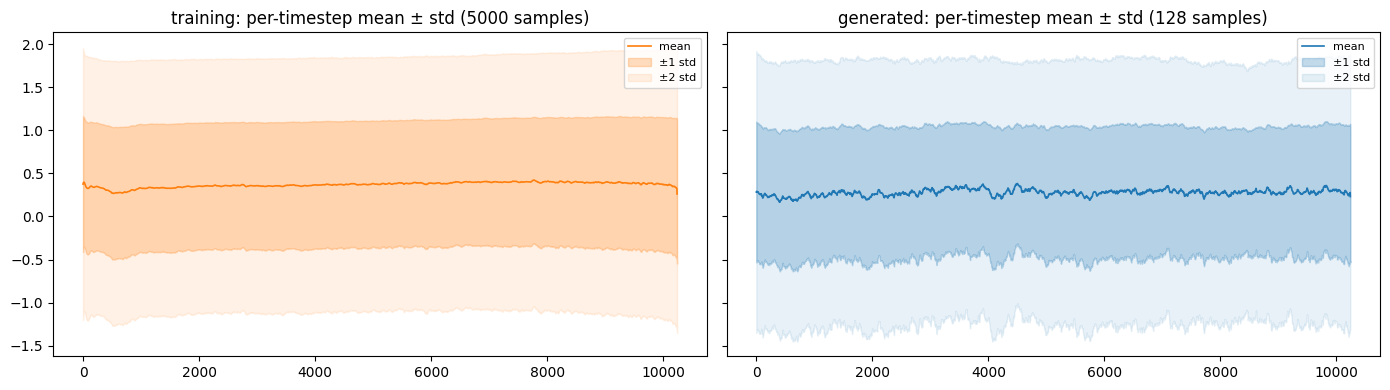

                   mean        std        min        max
training         0.3685     0.7468    -1.0000     1.0000
generated        0.2769     0.7701    -1.0592     1.0628


In [19]:
# Use a larger training slice for a stable reference
ref_idx = rng.choice(len(train_np), size=min(5000, len(train_np)), replace=False)
train_ref = train_np[ref_idx]
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, arr, name, color in [
    (axes[0], train_ref, "training", "tab:orange"),
    (axes[1], samples_np, "generated", "tab:blue"),
]:
    arr = np.asarray(arr)
    # (N, T) or (N, 1, T) — collapse channel if present
    if arr.ndim == 3 and arr.shape[1] == 1:
        arr = arr[:, 0, :]
    mu = arr.mean(axis=0)
    sd = arr.std(axis=0)
    t_axis = np.arange(mu.shape[0])  # match data, not SEQUENCE_LENGTH

    ax.plot(t_axis, mu, color=color, lw=1.2, label="mean")
    ax.fill_between(t_axis, mu - sd, mu + sd, color=color, alpha=0.25, label="±1 std")
    ax.fill_between(t_axis, mu - 2 * sd, mu + 2 * sd, color=color, alpha=0.1, label="±2 std")
    ax.set_title(f"{name}: per-timestep mean ± std ({len(arr)} samples)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Scalar summaries
print(f"{'':<12} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
for name, arr in [("training", train_ref), ("generated", samples_np)]:
    print(f"{name:<12} {arr.mean():>10.4f} {arr.std():>10.4f} {arr.min():>10.4f} {arr.max():>10.4f}")